# 07. 4차 모델링 : GWR

# 작업 순서

1. GWR 전략 구상
2. 좌표계(CRS) / 거리 척도 문제 해결
3. Train / Validation / Test 분할
4. GWR 피처셋 확정 — 로컬 공선성 진단
5. Bandwidth 선택
6. GWR 적합
7. Out-of-sample 예측 — mgwr.GWR.predict() 버그와 우회 구현
8. 성능 비교 (VS 기존 3개 모델)
9. Local coefficient 해석
10. GWR 예측값 저장

활용 데이터셋: dataset_final_ML1조.csv

# 1. GWR (Geographically Weighted Regression) 전략 구상


- Bandwidth(커널 폭)(핵심 하이퍼파라미터) **Train(2023)** 만 선택

- Test(2025 ~ 2026)는 최종 평가 1회에만 사용.

- `mgwr` 라이브러리의 `GWR.predict()`(out-of-sample 예측)에 인덱싱 버그가 있는 것을 확인함(아래 *7. Out-of-sample 예측 — mgwr.GWR.predict() 버그와 우회 구현* 참고). 이를 우회하기 위해
  GWR 정의(Fotheringham et al., 2002)를 따르는 out-of-sample 예측 함수를 직접 구현함.
- 좌표는 원본 데이터의 위도/경도(WGS84)를 그대로 쓰지 않고, 미터 단위 평면좌표계로 투영(projection)한 뒤 거리를 계산함(*2. 좌표계(CRS) / 거리 척도 문제 해결* 참고).


In [1]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pyproj import Transformer
from mgwr.gwr import GWR
from mgwr.sel_bw import Sel_BW
from mgwr.kernels import Kernel
from spglm.iwls import _compute_betas_gwr
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

from google.colab import files
print("▶ dataset_final_ML1조 파일 업로드")
uploaded = files.upload()
file_name = list(uploaded.keys())[0]

df = pd.read_csv(file_name)


▶ dataset_final_ML1조 파일 업로드


Saving dataset_final_ML1조.csv to dataset_final_ML1조.csv


In [2]:
!sudo apt-get install -y fonts-nanum

import matplotlib.font_manager as fm

font_path = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf'
fm.fontManager.addfont(font_path)
plt.rc('font', family='NanumBarunGothic')
plt.rcParams['axes.unicode_minus'] = False

print("등록된 폰트 확인:", [f.name for f in fm.fontManager.ttflist if 'Nanum' in f.name])

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 24 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 0s (53.7 MB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package fonts-nanum.
(Reading database ... 118332 files and direc

## 1-3. Target / Feature 확인 (기존 MLR·LightGBM·XGBoost와 동일 기준)

GWR은 로컬(지역 국소) 가중회귀이기 때문에, 전역 회귀(MLR)에서는 괜찮았던 변수도 좁은 반경 안에서는 값이 거의 상수가 되어
공선성 문제를 일으킬 수 있다. 실제로 어떤 변수가 문제인지는 아래 4절에서 직접 진단한다.


In [3]:
target = '면적당가격_만원'
features_tree = [
    'log_전용면적', '층', '주택연령', 'is_basement',
    'SK미래관거리', '보문역거리',
    '면적라벨_소형', '면적라벨_중형',
    '전월세구분_전세', '동그룹_안암동', '주택유형_연립'
]
print('LightGBM/XGBoost 피처 11개:', features_tree)


LightGBM/XGBoost 피처 11개: ['log_전용면적', '층', '주택연령', 'is_basement', 'SK미래관거리', '보문역거리', '면적라벨_소형', '면적라벨_중형', '전월세구분_전세', '동그룹_안암동', '주택유형_연립']


## 1-4. 좌표 확인

`dataset_final_ML1조.csv`에 **`위도`/`경도` 컬럼이 이미 존재**함

- 좌표를 새로 만들지 않고 이 컬럼을 그대로 사용.


In [6]:
print('위도/경도 결측치:', df[['위도','경도']].isnull().sum().to_dict())
print('위도 범위:', df['위도'].min(), '~', df['위도'].max())
print('경도 범위:', df['경도'].min(), '~', df['경도'].max())

n_unique_coords = df[['위도','경도']].drop_duplicates().shape[0]
print(f'고유 (위도,경도) 좌표 수: {n_unique_coords} / 전체 {df.shape[0]}행')

print(f'→ 같은 건물(주소)에서 여러 건 계약된 경우가 많다는 뜻. GWR 국소회귀 안정성에 영향 줄 수 있음.')


위도/경도 결측치: {'위도': 0, '경도': 0}
위도 범위: 37.5785528864785 ~ 37.5899871735891
경도 범위: 127.017350310758 ~ 127.031602810444
고유 (위도,경도) 좌표 수: 168 / 전체 1286행
→ 같은 건물(주소)에서 여러 건 계약된 경우가 많다는 뜻. GWR 국소회귀 안정성에 영향 줄 수 있음.


## 2. 좌표계(CRS) / 거리 척도 문제 해결

- `mgwr`의 기본 GWR 커널은 **Euclidean distance**를 사용.

**해결**: WGS84(EPSG:4326) → **EPSG:5186 (Korea 2000 / Central Belt 2010)**으로 투영.

미터 단위 평면좌표계이며
서울 지역 공간분석에 널리 쓰이는 국가 표준 좌표계.

투영 후에는 x, y가 모두 미터 단위이므로 Euclidean distance가
실제 지상 거리와 일치함.


In [7]:
transformer = Transformer.from_crs('EPSG:4326', 'EPSG:5186', always_xy=True)

def to_projected_coords(d):
    x, y = transformer.transform(d['경도'].values, d['위도'].values)
    return np.column_stack([x, y])

coords_all = to_projected_coords(df)
print('투영 후 좌표 범위 (m): x', coords_all[:,0].min(), '~', coords_all[:,0].max(),
      ' / y', coords_all[:,1].min(), '~', coords_all[:,1].max())
print('연구지역 실제 크기(m): 동서', coords_all[:,0].max()-coords_all[:,0].min(),
      ', 남북', coords_all[:,1].max()-coords_all[:,1].min())


투영 후 좌표 범위 (m): x 201532.5599999788 ~ 202791.2800000294  / y 553222.7200000195 ~ 554492.0400000222
연구지역 실제 크기(m): 동서 1258.7200000505836 , 남북 1269.3200000026263


## 3. Train / Validation / Test 분할

- **Train**: `data_split=='train' & 계약연도==2023` — GWR bandwidth 선택 + 계수 적합(calibration)에만 사용
- **Validation**: `data_split=='train' & 계약연도==2024` — bandwidth로 학습된 모델의 out-of-sample 일반화를 사전 점검(진단용, 아래 8절)
- **Test**: `data_split=='test'` (2025~2026) — **최종 평가에 단 1회만 사용**. Test는 bandwidth 선택에도, Val 점검에도 전혀 관여하지 않음.


In [9]:
train_df = df[(df['data_split'] == 'train') & (df['계약연도'] == 2023)].copy()
val_df   = df[(df['data_split'] == 'train') & (df['계약연도'] == 2024)].copy()
test_df  = df[df['data_split'] == 'test'].copy()

print(f"Train(2023)     : {len(train_df)}건")
print(f"Validation(2024): {len(val_df)}건")
print(f"Test(2025~2026) : {len(test_df)}건")

coords_train = to_projected_coords(train_df)
coords_val   = to_projected_coords(val_df)
coords_test  = to_projected_coords(test_df)


Train(2023)     : 332건
Validation(2024): 362건
Test(2025~2026) : 592건


### 4. GWR 피처셋 확정 — 로컬 공선성 진단

1. 트리 모델의 11개 피처를 그대로 GWR에 넣으면 어떻게 되는지 먼저 진단

`mgwr`의 커널(bisquare, adaptive)로 각 Train 지점의
로컬 가중 설계행렬 X'WX의 rank를 계산해, 파라미터 수(변수 수+1)보다 rank가 낮게 나오는(=국소적으로 특이/singular인) 지점이
몇 개인지 계산.


In [10]:
def count_locally_singular(feature_list, bw_value, coords, data):
    X = data[feature_list].values.astype(float)
    Xc = np.column_stack([np.ones(len(X)), X])
    n = len(X)
    bad = 0
    for i in range(n):
        w = Kernel(i, coords, bw_value, fixed=False, function='bisquare').kernel
        Xw = Xc * np.sqrt(w)[:, None]
        rank = np.linalg.matrix_rank(Xw, tol=1e-8)
        if rank < Xc.shape[1]:
            bad += 1
    return bad, n

# is_basement는 Train(2023)에 3건뿐이라 애초에 로컬 회귀에 넣을 수 없음
print('Train(2023) is_basement 건수:', train_df['is_basement'].sum(), '/', len(train_df))

# 나머지 10개 피처(is_basement 제외)로 전형적인 adaptive bandwidth(60~150 이웃) 범위에서 진단
features_no_basement = [f for f in features_tree if f != 'is_basement']
for bwv in [60, 100, 150]:
    bad, n = count_locally_singular(features_no_basement, bwv, coords_train, train_df)
    print(f'bw={bwv}: 국소 특이(singular) 지점 {bad}/{n}건 (피처 10개 전체 투입 시)')


Train(2023) is_basement 건수: 3 / 332
bw=60: 국소 특이(singular) 지점 222/332건 (피처 10개 전체 투입 시)
bw=100: 국소 특이(singular) 지점 131/332건 (피처 10개 전체 투입 시)
bw=150: 국소 특이(singular) 지점 66/332건 (피처 10개 전체 투입 시)


전형적인 bandwidth 범위(60 ~ 150 이웃)에서 **전체 Train의 20 ~ 70%에서 로컬 설계행렬이 특이(singular)**가 됨.

`log_전용면적`의 계수는 이 경우 계산 자체가 불가능하거나(NaN) 극단적으로 불안정해짐.

원인 변수를 하나씩 제거하며 확인한 결과:

| 변수 | 문제 |
|---|---|
| `is_basement` | Train(2023) 332건 중 **3건**뿐 — 어떤 크기의 로컬 창(window)에서도 분산이 사실상 0 |
| `면적라벨_소형` | `log_전용면적`과 로컬 창 안에서 거의 완전 공선 (MLR도 전역 VIF>10으로 동일 변수를 이미 제거한 바 있음 — GWR에서는 그 문제가 국소적으로 훨씬 심해짐) |
| `동그룹_안암동` | **위치 자체를 나타내는 더미 변수**라서 좁은 반경(bandwidth) 안에서는 안암동/보문동 중 한쪽으로 거의 고정됨 → 상수항과 사실상 동일해져 특이 발생. 개념적으로도 GWR이 이미 계수의 공간적 변화로 동/보문 차이를 표현하므로 중복 정보임 |
| `주택유형_연립` | 연립주택이 특정 블록에 밀집 — 좁은 반경에서 상수화되며 동일한 문제 발생 |

2. 아래에서 이 4개를 제외한 **7개 피처**로 다시 진단해 안정성을 확인


In [11]:
features_gwr = ['log_전용면적', '층', '주택연령', 'SK미래관거리', '보문역거리', '전월세구분_전세', '면적라벨_중형']

for bwv in [60, 100, 150, 200]:
    bad, n = count_locally_singular(features_gwr, bwv, coords_train, train_df)
    print(f'bw={bwv}: 국소 특이 지점 {bad}/{n}건 (GWR 최종 7개 피처)')

print()
print('GWR 최종 피처(7개):', features_gwr)
print('LightGBM/XGBoost(11개) 대비 제외:', [f for f in features_tree if f not in features_gwr])


bw=60: 국소 특이 지점 0/332건 (GWR 최종 7개 피처)
bw=100: 국소 특이 지점 0/332건 (GWR 최종 7개 피처)
bw=150: 국소 특이 지점 0/332건 (GWR 최종 7개 피처)
bw=200: 국소 특이 지점 0/332건 (GWR 최종 7개 피처)

GWR 최종 피처(7개): ['log_전용면적', '층', '주택연령', 'SK미래관거리', '보문역거리', '전월세구분_전세', '면적라벨_중형']
LightGBM/XGBoost(11개) 대비 제외: ['is_basement', '면적라벨_소형', '동그룹_안암동', '주택유형_연립']


3. **GWR 최종 피처셋은 이 7개로 확정**


In [12]:
Xr_train = train_df[features_gwr].values.astype(float)
X_train  = np.column_stack([np.ones(len(train_df)), Xr_train])
y_train  = train_df[[target]].values.astype(float)

X_val  = np.column_stack([np.ones(len(val_df)),  val_df[features_gwr].values.astype(float)])
y_val  = val_df[[target]].values.astype(float)
X_test = np.column_stack([np.ones(len(test_df)), test_df[features_gwr].values.astype(float)])
y_test = test_df[[target]].values.astype(float)


## 5. Bandwidth 선택 (AICc, golden-section search) — Train(2023)만 사용

`mgwr.sel_bw.Sel_BW`는 AICc를 최소화하는 bandwidth를 golden-section search + leave-one-out 방식으로 탐색함.

이 과정은 **Train(2023) 데이터에만 접근**하며, Validation·Test는 전혀 사용하지 않음.

Kernel은 `bisquare`(adaptive) — 같은 주소에서 여러 번 거래된 지점이 많아(1절), 고정 반경(fixed) 커널보다 이웃 개수 기준(adaptive) 커널이 빈 창(empty window) 문제에서 더 안전하다는 것을 확인.


In [13]:
sel = Sel_BW(coords_train, y_train, Xr_train, kernel='bisquare', fixed=False)
bw = sel.search(criterion='AICc')
print(f'선택된 bandwidth: {bw:.0f} (최근접 이웃 개수, Train n={len(train_df)}의 {bw/len(train_df)*100:.1f}%)')

from scipy.spatial import cKDTree
tree = cKDTree(coords_train)
dists, _ = tree.query(coords_train, k=int(bw)+1)
print(f'bandwidth에 해당하는 반경(중앙값): 약 {np.median(dists[:, -1]):.0f}m')


선택된 bandwidth: 58 (최근접 이웃 개수, Train n=332의 17.5%)
bandwidth에 해당하는 반경(중앙값): 약 279m


## 6. GWR 적합 (Train 계수 및 로컬 진단)


In [17]:
gwr_model = GWR(coords_train, y_train, Xr_train, bw, kernel='bisquare', fixed=False)
gwr_results = gwr_model.fit()

print('=' * 60)
print(' [GWR] Train(2023) 적합 결과')
print('=' * 60)
print(f'▶ Train 전역-등가 R² : {gwr_results.R2:.4f}')
print(f'▶ AICc               : {gwr_results.aicc:.1f}')
print(f'▶ Local R² 범위       : {np.nanmin(gwr_results.localR2):.3f} ~ {np.nanmax(gwr_results.localR2):.3f} (평균 {np.nanmean(gwr_results.localR2):.3f})')
print(f'▶ NaN 계수 개수       : {np.isnan(gwr_results.params).sum()}')
print('=' * 60)


 [GWR] Train(2023) 적합 결과
▶ Train 전역-등가 R² : 0.8661
▶ AICc               : 4357.9
▶ Local R² 범위       : 0.659 ~ 0.942 (평균 0.789)
▶ NaN 계수 개수       : 0


## 7. Out-of-sample 예측 — `mgwr.GWR.predict()` 버그와 우회 구현

`mgwr` 2.2.1의 `GWR.predict(points, P)`를 Validation(362건)에 그대로 적용하면 다음 에러가 나타나는 것을 확인:

```
IndexError: index 336 is out of bounds for axis 0 with size 332
```

원인을 `mgwr/gwr.py`의 `_local_fit()`에서 확인함: out-of-sample 예측 모드(`self.points is not None`)에서도
예측값 계산이 `predy = np.dot(self.X[i], betas)[0]`로 되어 있는데, 이 `self.X`는 **calibration(Train) 설계행렬**임.
즉 새 지점의 좌표로 만든 가중치(`wi`)는 올바르게 계산하면서도, 정작 예측에 곱하는 설명변수는 새 지점(`P[i]`)이 아니라
**Train 지점의 설명변수(`X[i]`)를 그대로 재사용**하는 인덱싱 버그인 것. Validation 개수(362) > Train 개수(332)라서 인덱스 초과로 바로 에러가 났지만,
개수가 같거나 더 적었다면 에러 없이 **조용히 틀린 예측값**을 냈을 것.

이를 우회하기 위해 GWR의 원래 정의(Fotheringham, Brunsdon & Charlton, 2002)를 따르는 out-of-sample 예측 함수를 직접 구현함:
새 지점 j에 대해 (1) Train 좌표까지의 거리로 bisquare 가중치 계산 → (2) Train (X, y)로 가중최소제곱(WLS) 적합 →
(3) **새 지점의 설명변수 `P[j]`**로 예측. `mgwr.kernels.Kernel`과 `spglm.iwls._compute_betas_gwr`를 재사용해 (1)(2)만 라이브러리에 맡기고
(3)만 직접 수정함.


In [18]:
def gwr_predict_oos(coords_train, X_train, y_train, bw, coords_new, X_new):
    """mgwr.GWR.predict()의 out-of-sample 인덱싱 버그를 피해 직접 구현한 예측 함수."""
    m = coords_new.shape[0]
    preds = np.zeros(m)
    betas_all = np.zeros((m, X_train.shape[1]))
    for j in range(m):
        wi = Kernel(j, coords_train, bw, fixed=False, function='bisquare',
                    points=coords_new).kernel.reshape(-1, 1)
        betas, _ = _compute_betas_gwr(y_train, X_train, wi)
        preds[j] = np.dot(X_new[j], betas)[0]
        betas_all[j] = betas.flatten()
    return preds, betas_all

val_pred, val_betas = gwr_predict_oos(coords_train, X_train, y_train, bw, coords_val, X_val)

val_r2   = r2_score(y_val, val_pred)
val_rmse = np.sqrt(mean_squared_error(y_val, val_pred))
val_mae  = mean_absolute_error(y_val, val_pred)
print('=' * 60)
print(' [GWR] Validation(2024) — 진단용 (bandwidth 재조정에는 사용 안 함)')
print('=' * 60)
print(f'▶ R²  : {val_r2:.4f}')
print(f'▶ RMSE: {val_rmse:.1f} 만원/m²')
print(f'▶ MAE : {val_mae:.1f} 만원/m²')
print('=' * 60)


 [GWR] Validation(2024) — 진단용 (bandwidth 재조정에는 사용 안 함)
▶ R²  : 0.7421
▶ RMSE: 176.2 만원/m²
▶ MAE : 128.0 만원/m²


In [19]:
# 최종 평가는 Test(2025~2026)에서 단 한 번만 수행
test_pred, test_betas = gwr_predict_oos(coords_train, X_train, y_train, bw, coords_test, X_test)

test_r2   = r2_score(y_test, test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))
test_mae  = mean_absolute_error(y_test, test_pred)
print('=' * 60)
print(' [GWR] Test(2025~2026) 최종 예측 성능')
print('=' * 60)
print(f'▶ Test R-squared (설명력): {test_r2:.4f}')
print(f'▶ Test RMSE (평균 오차액): {test_rmse:.1f} 만원/m²')
print(f'▶ Test MAE  (절대 오차액): {test_mae:.1f} 만원/m²')
print(f'▶ NaN 계수 개수: {np.isnan(test_betas).sum()}')
print('=' * 60)


 [GWR] Test(2025~2026) 최종 예측 성능
▶ Test R-squared (설명력): 0.6817
▶ Test RMSE (평균 오차액): 194.6 만원/m²
▶ Test MAE  (절대 오차액): 141.4 만원/m²
▶ NaN 계수 개수: 0


## 8. 성능 비교 (VS 기존 3개 모델)




In [20]:
results_summary = pd.DataFrame({
    'Model':     ['MLR2', 'GWR', 'XGBoost', 'LightGBM'],
    'Test_R2':   [0.649, test_r2, 0.7984, 0.8051],
    'Test_RMSE': [204.2, test_rmse, 154.9, 152.2],
    'Test_MAE':  [159.3, test_mae, 117.7, 110.2],
    'n_features':[9, len(features_gwr), 11, 11],
    'Train_n':   [694, len(train_df), 332, 332],
})
results_summary


,Model,Test_R2,Test_RMSE,Test_MAE,n_features,Train_n
0,MLR2,0.649000,204.200000,159.300000,9,694
1,GWR,0.681708,194.568382,141.395654,7,332
2,XGBoost,0.798400,154.900000,117.700000,11,332
3,LightGBM,0.805100,152.200000,110.200000,11,332


## 9. Local coefficient 해석 — 공간적 이질성(spatial heterogeneity)

GWR의 목적은 단일 성능 지표가 아니라 **"어느 지역에서 어떤 변수가 가격에 더/덜 영향을 주는가"**를 보는 것이기 때문에


Train(2023) 계수(로컬 회귀 결과)를 좌표에 매핑해 살펴봄.


In [21]:
coef_names = ['const'] + features_gwr
for k, name in enumerate(coef_names):
    col = gwr_results.params[:, k]
    print(f'{name:12s}  min={col.min():9.2f}  max={col.max():9.2f}  mean={col.mean():9.2f}')


const         min=  -480.87  max=  7401.69  mean=  2669.56
log_전용면적      min=  -784.67  max=   -61.68  mean=  -361.12
층             min=   -33.34  max=    89.44  mean=    26.86
주택연령          min=   -46.16  max=    17.12  mean=   -13.34
SK미래관거리       min=    -2.98  max=     2.00  mean=    -0.10
보문역거리         min=    -4.59  max=     1.80  mean=    -0.95
전월세구분_전세      min=  -418.16  max=   338.58  mean=  -109.96
면적라벨_중형       min=  -154.05  max=   191.84  mean=    45.91


저장: outputs/graphs/08_gwr_local_coef_map.png


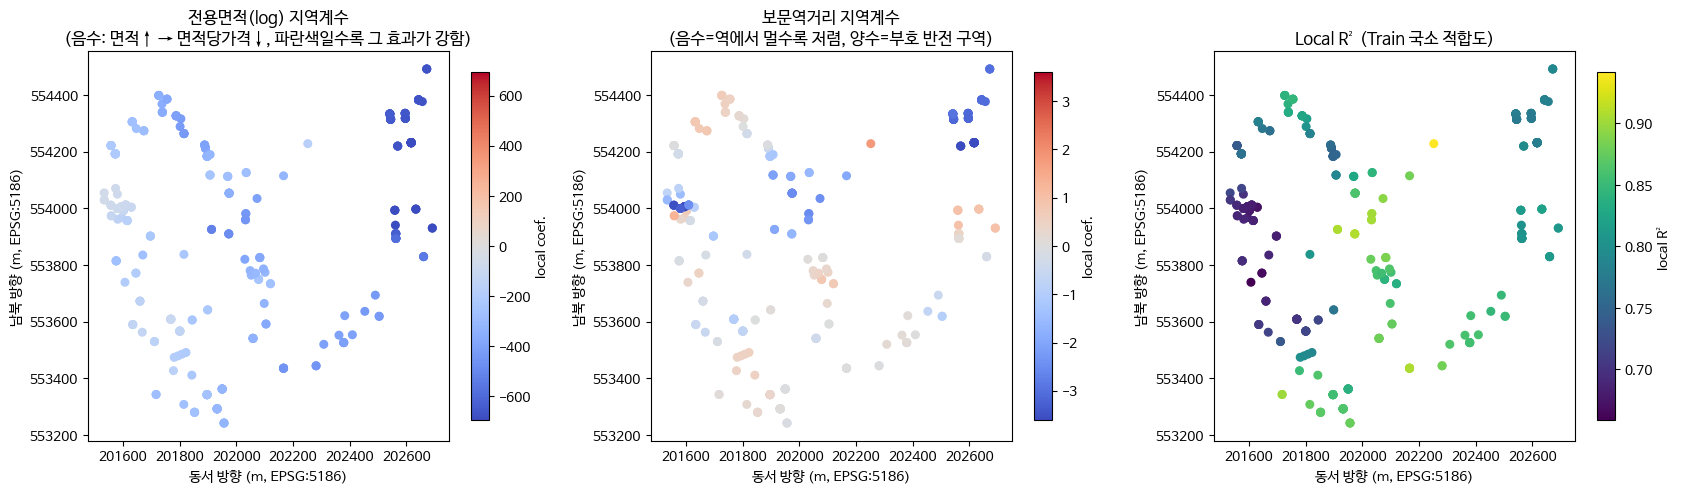

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

idx_area = coef_names.index('log_전용면적')
idx_bomun = coef_names.index('보문역거리')

col1 = gwr_results.params[:, idx_area]
vmax1 = np.percentile(np.abs(col1), 95)
sc1 = axes[0].scatter(coords_train[:, 0], coords_train[:, 1], c=col1, cmap='coolwarm',
                       vmin=-vmax1, vmax=vmax1, s=30)
plt.colorbar(sc1, ax=axes[0], shrink=0.8, label='local coef.')
axes[0].set_title('전용면적(log) 지역계수\n(음수: 면적↑ → 면적당가격↓, 파란색일수록 그 효과가 강함)')

col2 = gwr_results.params[:, idx_bomun]
vmax2 = np.percentile(np.abs(col2), 95)
sc2 = axes[1].scatter(coords_train[:, 0], coords_train[:, 1], c=col2, cmap='coolwarm',
                       vmin=-vmax2, vmax=vmax2, s=30)
plt.colorbar(sc2, ax=axes[1], shrink=0.8, label='local coef.')
axes[1].set_title('보문역거리 지역계수\n(음수=역에서 멀수록 저렴, 양수=부호 반전 구역)')

sc3 = axes[2].scatter(coords_train[:, 0], coords_train[:, 1], c=gwr_results.localR2,
                       cmap='viridis', s=30)
plt.colorbar(sc3, ax=axes[2], shrink=0.8, label='local R²')
axes[2].set_title('Local R² (Train 국소 적합도)')

for ax in axes:
    ax.set_xlabel('동서 방향 (m, EPSG:5186)')
    ax.set_ylabel('남북 방향 (m, EPSG:5186)')
    ax.set_aspect('equal')

plt.tight_layout()

OUT_CANDIDATES = [Path('outputs/graphs'), Path('../outputs/graphs')]
out_dir = next((p for p in OUT_CANDIDATES if p.exists()), Path('outputs/graphs'))
out_dir.mkdir(parents=True, exist_ok=True)
fig_path = out_dir / '08_gwr_local_coef_map.png'
plt.savefig(fig_path, dpi=120, bbox_inches='tight')
print(f'저장: {fig_path}')
plt.show()


## 10. GWR 예측값 저장


In [25]:
pred_records = []
for split_name, d, y_arr, pred_arr in [
    ('val_2024', val_df, y_val.flatten(), val_pred),
    ('test', test_df, y_test.flatten(), test_pred),
]:
    tmp = pd.DataFrame({
        'data_split': split_name,
        'row_id': d.index,
        'actual': y_arr,
        'gwr_pred': pred_arr,
    })
    pred_records.append(tmp)

predictions_df = pd.concat(pred_records, ignore_index=True)

predictions_df.to_csv('gwr_predictions.csv', index=False)

from google.colab import files
files.download('gwr_predictions.csv')

predictions_df.head()


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

,data_split,row_id,actual,gwr_pred
0,val_2024,332,823.471883,956.994260
1,val_2024,333,1283.333333,1339.409145
2,val_2024,334,1276.901004,1200.742915
3,val_2024,335,1330.502477,1038.710791
4,val_2024,336,312.821422,199.037123
